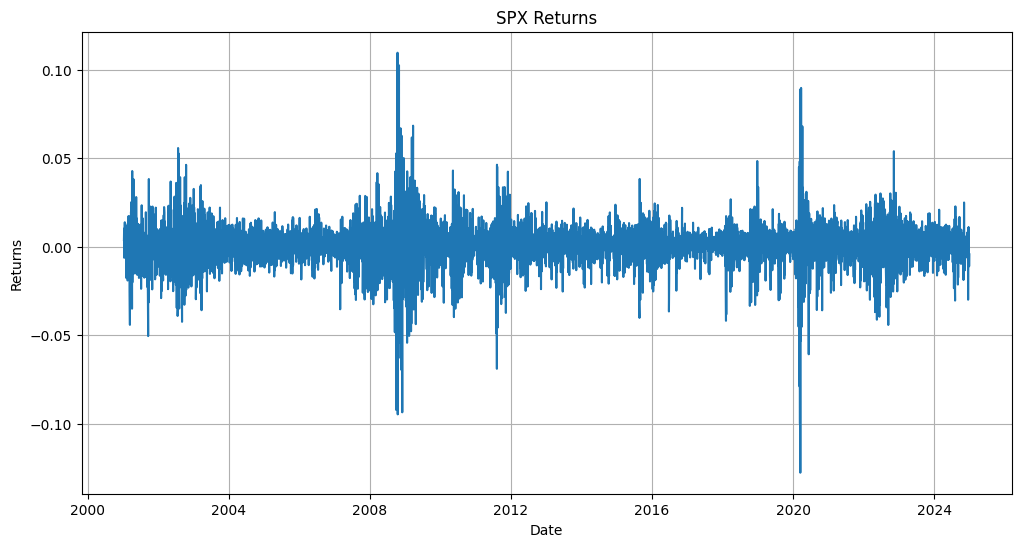

In [12]:
import pandas as pd
import numpy as np

# Read the SPX data
spx = pd.read_csv('spx_data.csv', index_col=0, parse_dates=True)
spx.index = pd.to_datetime(spx.index)

# Calculate returns
spx['returns'] = np.log(spx['Close']).diff().dropna()

# Plot returns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(spx.index.values, spx['returns'].values)
plt.title('SPX Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid(True)
plt.show()


In [18]:
from arch.univariate import ARX, GARCH, Normal
from arch.univariate.base import implicit_constant
import numpy as np
from numba import jit

class CustomMean(ARX):
    name = 'Custom Mean'
    
    def __init__(self, y=None, x=None, lags=1, constant=True):
        super().__init__(y=y, x=x, lags=lags, constant=constant)
        self.num_params = lags + (1 if constant else 0) + 1  # Add 1 for risk premium parameter
        self._parameter_names = ['constant'] if constant else []
        self._parameter_names.extend([f'ar{i+1}' for i in range(lags)])
        self._parameter_names.append('risk_premium')  # Add risk premium parameter name

    def compute_mean(self, params, resids, var, backcast, var_bounds):
        constant = params[0] if self.constant else 0
        mu = np.full_like(resids, constant)
        
        y = self._y
        for i in range(self.lags):
            param_idx = i + (1 if self.constant else 0)
            lag_idx = i + 1
            mu[lag_idx:] += params[param_idx] * y[:-lag_idx]
            
        # Add risk premium term (GARCH-in-Mean)
        risk_premium_idx = self.num_params - 1
        mu += params[risk_premium_idx] * np.sqrt(var)
            
        if self._x is not None:
            mu += np.asarray(self._x) @ params[self.num_params-1:]
        return mu

class CustomVolatility(GARCH):
    name = 'Custom Volatility'
    
    def __init__(self, p=1, o=1, q=1, power=2.0):
        super().__init__(p=p, o=o, q=q, power=power)

    @staticmethod
    @jit(nopython=True)
    def _compute_variance(parameters, resids, var, backcast, p, o, q):
        omega = parameters[0]
        alpha = parameters[1:1+p]
        gamma = parameters[1+p:1+p+o]
        beta = parameters[1+p+o:]
        
        var[0] = backcast
        T = len(resids)
        
        for t in range(1, T):
            var[t] = omega
            for j in range(p):
                if t-1-j >= 0:
                    var[t] += alpha[j] * resids[t-1-j]**2
            for j in range(o):
                if t-1-j >= 0:
                    var[t] += gamma[j] * resids[t-1-j]**2 * (resids[t-1-j] < 0)
            for j in range(q):
                if t-1-j >= 0:
                    var[t] += beta[j] * var[t-1-j]
        return var

    def compute_variance(self, parameters, resids, sigma2, backcast, var_bounds):
        var = np.zeros_like(resids)
        return self._compute_variance(parameters, resids, var, backcast, self.p, self.o, self.q)

custom_mean = CustomMean(y=spx['returns'].dropna(), lags=0)
custom_vol = CustomVolatility(p=1, o=1, q=1)

model = custom_mean
model.volatility = custom_vol
model.distribution = Normal()

result = model.fit(disp='off')
print(result.summary())



/Users/gongiuzhang/miniconda3/lib/python3.8/site-packages/arch/univariate/base.py:310: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001472. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/gongiuzhang/miniconda3/lib/python3.8/site-packages/arch/univariate/distribution.py:450: RuntimeWarning: divide by zero encountered in log
  lls = -0.5 * (log(2 * pi) + log(sigma2) + resids ** 2.0 / sigma2)
/Users/gongiuzhang/miniconda3/lib/python3.8/site-packages/arch/univariate/distribution.py:450: RuntimeWarning: divide by zero encountered in true_divide
  lls = -0.5 * (log(2 * pi) + log(sigma2) + resids ** 2.0 / sigma2)
/Users/gongiuzhang/miniconda3/lib/python3.8/site-packages/arch/univariate/distribution.py

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (6,)  and requested shape (5,)

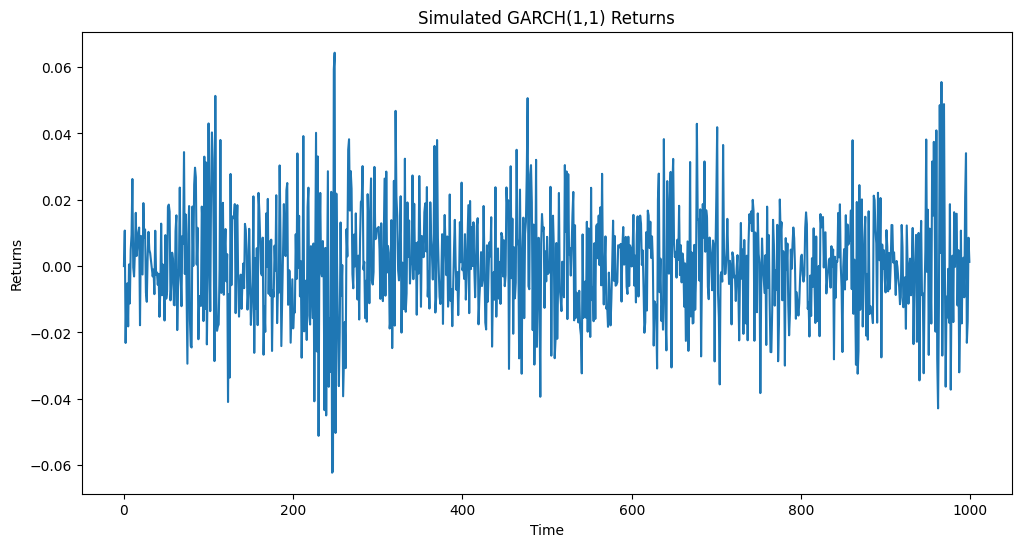

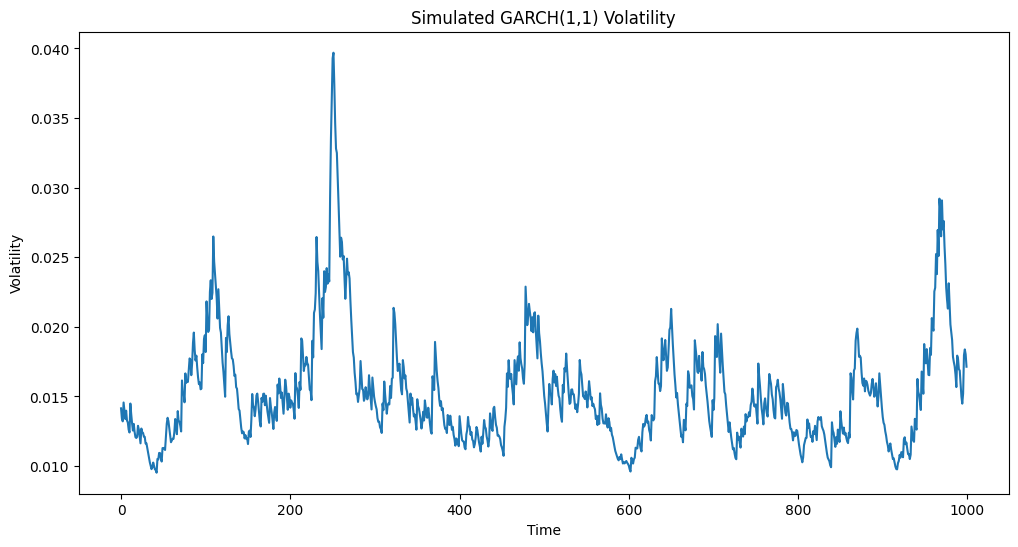

In [19]:
# Set parameters for GARCH(1,1) simulation
T = 1000  # Number of observations
omega = 0.00001  # Constant term
alpha = 0.1  # ARCH parameter
beta = 0.85  # GARCH parameter
mu = 0

# Initialize arrays
returns = np.zeros(T)
sigma2 = np.zeros(T)
sigma2[0] = omega / (1 - alpha - beta)  # Initialize variance at unconditional value

# Generate returns using GARCH(1,1) process
for t in range(1, T):
    # Generate random shock
    z = np.random.standard_normal()
    
    # Calculate return
    returns[t] = mu + np.sqrt(sigma2[t-1]) * z
    
    # Update variance
    sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]

# Plot simulated returns
plt.figure(figsize=(12, 6))
plt.plot(returns)
plt.title('Simulated GARCH(1,1) Returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.show()

# Plot simulated volatility
plt.figure(figsize=(12, 6))
plt.plot(np.sqrt(sigma2))
plt.title('Simulated GARCH(1,1) Volatility')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.show()

